<a href="https://colab.research.google.com/github/hhanoudi/AIHC-5010-Winter-2026hhs/blob/main/Assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

problem 1

In [ ]:
import pandas as pd
from google.cloud import storage
from google.auth.credentials import AnonymousCredentials
import io

# Define bucket and blob information
bucket_name = 'cloud-samples-data'
blob_name = 'ml-engine/census/data/adult.data.csv'

# Create a client object with anonymous credentials
storage_client = storage.Client(credentials=AnonymousCredentials())

# Get the bucket and blob
bucket = storage_client.bucket(bucket_name)
blob = bucket.blob(blob_name)

# Download the blob content as a string
csv_data = blob.download_as_string()

# Load the data into a DataFrame using pandas
df = pd.read_csv(io.StringIO(csv_data.decode('utf-8')), header=None)

In [ ]:
def load_gcs_to_dataframe(bucket, blob_name, column_names=None):
    """
    Creates a blob using the bucket and the blob name, loads the blob data
    into a DataFrame, and sets custom column names if provided.
    """
    # Create the blob using the bucket and the blob name
    blob = bucket.blob(blob_name)

    # Download the blob content as a string
    csv_data = blob.download_as_string()

    # Load the blob data into a DataFrame
    if column_names:
        df_loaded = pd.read_csv(io.StringIO(csv_data.decode('utf-8')), names=column_names, header=None)
    else:
        df_loaded = pd.read_csv(io.StringIO(csv_data.decode('utf-8')), header=None)

    return df_loaded

In [ ]:
COLUMN_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income_bracket'
]

def load_csv_blob(blob_name, bucket, column_names=[]):
    """
    Loads the CSV blob into a pandas DataFrame using custom column names.
    """
    blob = bucket.blob(blob_name)
    csv_data = blob.download_as_string()

    if len(column_names) > 0:
        df_loaded = pd.read_csv(io.StringIO(csv_data.decode('utf-8')), names=column_names, header=None)
    else:
        df_loaded = pd.read_csv(io.StringIO(csv_data.decode('utf-8')), header=None)

    return df_loaded

# Test the function with the provided column names
df_named = load_csv_blob(blob_name, bucket, COLUMN_NAMES)
display(df_named.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


problem 2

In [4]:
import pandas as pd
import pandas_gbq

# Define the project ID and SQL query
project_id = '254818231894'
query = """
SELECT
  date,
  new_confirmed,
  new_deceased
FROM
  `bigquery-public-data.covid19_open_data.covid19_open_data`
WHERE
  country_name = 'Mexico'
  AND EXTRACT(YEAR FROM date) = 2021
ORDER BY
  date ASC
"""

# Run query using pandas-gbq which handles Colab auth integration natively
df_covid = pandas_gbq.read_gbq(query, project_id=project_id)

# Verify work
print(f"Number of rows in the DataFrame: {len(df_covid)}")
display(df_covid.head())


Downloading: 100%|██████████|
Number of rows in the DataFrame: 911770


,date,new_confirmed,new_deceased
0,2021-01-01,<NA>,<NA>
1,2021-01-01,<NA>,<NA>
2,2021-01-01,<NA>,<NA>
3,2021-01-01,<NA>,<NA>
4,2021-01-01,<NA>,<NA>


problem 3

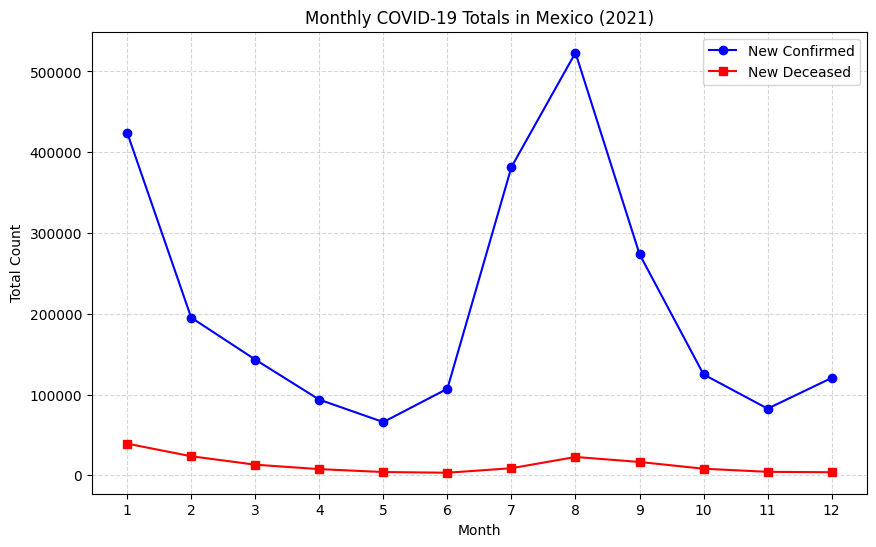

In [6]:
import matplotlib.pyplot as plt

# Map the existing df_covid variable to mexico_covid_df
mexico_covid_df = df_covid.copy()

# Convert date column to datetime to easily extract the month
mexico_covid_df['date'] = pd.to_datetime(mexico_covid_df['date'])

# Create a new column containing only the month part of the date
mexico_covid_df['month'] = mexico_covid_df['date'].apply(lambda dt: dt.month)

# Convert metric columns to numeric, forcing errors to NaN so sum can aggregate properly
mexico_covid_df['new_confirmed'] = pd.to_numeric(mexico_covid_df['new_confirmed'], errors='coerce')
mexico_covid_df['new_deceased'] = pd.to_numeric(mexico_covid_df['new_deceased'], errors='coerce')

# Group by month and sum the numeric columns
monthly_totals = mexico_covid_df.groupby('month')[['new_confirmed', 'new_deceased']].sum()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(monthly_totals.index, monthly_totals['new_confirmed'], marker='o', label='New Confirmed', color='blue')
plt.plot(monthly_totals.index, monthly_totals['new_deceased'], marker='s', label='New Deceased', color='red')

# Customize the plot
plt.title('Monthly COVID-19 Totals in Mexico (2021)')
plt.xlabel('Month')
plt.ylabel('Total Count')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()

In [7]:
# Display descriptive statistics for the monthly_totals dataframe
display(monthly_totals.describe())

,new_confirmed,new_deceased
count,12.0,12.0
mean,211335.083333,12880.833333
std,153340.558641,10920.432557
min,65871.0,3152.0
25%,103763.0,4202.0
50%,134059.0,8422.5
75%,300733.25,18024.75
max,523222.0,39156.0
